*This is a google colab based notebook used for model inference*

### Dependencies & Installations

In [ ]:
!pip install -q transformers supervision opencv-python pillow torch torchvision ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 83.9 MB/s eta 0:00:00


In [ ]:
from google.colab import userdata
userdata.get('HF_TOKEN')

### Owlv2 Temp

In [ ]:
import torch
import numpy as np
import supervision as sv
from transformers import Owlv2Processor, Owlv2ForObjectDetection
from PIL import Image
import cv2
import os
import colorsys
from IPython.display import Video

class LogoDetector:
    def __init__(self, model_id="google/owlv2-base-patch16-ensemble"):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.processor = Owlv2Processor.from_pretrained(model_id)
        self.model = Owlv2ForObjectDetection.from_pretrained(model_id).to(self.device)
        self.model.eval()

        self.queries = [
            # --- Broadcasting & Digital Overlays ---
            "a television network watermark",
            "a channel logo in the corner of the screen",
            "a digital graphic logo",
            "a sports broadcast logo",

            # --- Sports & Apparel (Tennis, Volleyball, Billiards) ---
            "a brand logo on a sports shirt",
            "a sponsor logo on athletic shorts",
            "a logo on a tennis racket",
            "a sportswear brand logo",
            "a sponsor logo on a sports uniform",

            # --- Advertising Boards & Venues ---
            "an advertising board sponsor logo",
            "a logo printed on a sports court surface",
            "a sponsor logo on a billiard table border",
            "a tournament logo on a wall",
            "a brand name printed on a banner",

            # --- Products & Commercial Packaging (Food, Meds, Toys) ---
            "a brand name on medicine packaging",
            "a company logo on a food box",
            "a brand logo on a frozen food bag",
            "a toy brand logo",
            "a corporate logo on a product label",
            "a logo on a security camera device",

            # --- General / Fallback (EXPANDED) ---
            "a corporate trademark",
            "a small brand icon",
            "a company symbol",
            "a text-based brand logo",
            "a commercial brand mark",
            "an enterprise emblem",
            "a distinctive brand insignia",
            "a recognizable company badge",
            "a generic logo",
            "an organization's crest",
            "a commercial watermark",
            "a manufacturer's mark",
            "an official logo graphic",
            "a product",
            "a potential logo",
            "a company",
            "a brand"
        ]

    def run_example(self, image: Image, threshold=0.1, nms_threshold=0.3):
        texts = [self.queries]
        inputs = self.processor(text=texts, images=image, return_tensors="pt").to(self.device)

        with torch.no_grad():
            outputs = self.model(**inputs)

        target_sizes = torch.Tensor([image.size[::-1]]).to(self.device)

        results = self.processor.image_processor.post_process_object_detection(
            outputs=outputs,
            target_sizes=target_sizes,
            threshold=threshold,
        )

        scores = results[0]['scores'].cpu().numpy().reshape(-1, 1)
        boxes = results[0]['boxes'].cpu().numpy()
        labels = results[0]['labels'].cpu().numpy()

        if len(boxes) == 0:
            return {'boxes': np.array([]), 'scores': np.array([]), 'labels': np.array([])}

        detections = np.hstack((boxes, scores))
        keep_idxs = sv.box_non_max_suppression(detections, iou_threshold=nms_threshold)

        return {
            'boxes': boxes[keep_idxs],
            'scores': scores.flatten()[keep_idxs],
            'labels': labels[keep_idxs]
        }

    def run_examples(self, images, threshold=0.1, nms_threshold=0.3):
        texts = [self.queries] * len(images)
        inputs = self.processor(text=texts, images=images, return_tensors="pt").to(self.device)

        with torch.no_grad():
            outputs = self.model(**inputs)

        target_sizes = torch.Tensor([img.size[::-1] for img in images]).to(self.device)

        batch_results = self.processor.image_processor.post_process_object_detection(
            outputs=outputs,
            target_sizes=target_sizes,
            threshold=threshold,
        )

        all_results = []
        for result in batch_results:
            scores = result['scores'].cpu().numpy().reshape(-1, 1)
            boxes = result['boxes'].cpu().numpy()
            labels = result['labels'].cpu().numpy()

            if len(boxes) == 0:
                all_results.append({'boxes': np.array([]), 'scores': np.array([]), 'labels': np.array([])})
                continue

            detections = np.hstack((boxes, scores))
            keep_idxs = sv.box_non_max_suppression(detections, iou_threshold=nms_threshold)

            all_results.append({
                'boxes': boxes[keep_idxs],
                'scores': scores.flatten()[keep_idxs],
                'labels': labels[keep_idxs]
            })
        return all_results

    def draw_boxes(self, image: Image, result: dict):
        boxes = result['boxes']
        scores = result['scores']
        labels = result['labels']
        logos = []

        for box in boxes:
            x1, y1, x2, y2 = [round(v, 2) for v in box.tolist()]
            logos.append(image.crop((x1, y1, x2, y2)))

        return logos, scores, boxes, labels

    def process_image(self, image: Image, threshold: float = 0.1, nms_threshold: float = 0.3):
        result = self.run_example(image, threshold=threshold, nms_threshold=nms_threshold)
        logos, scores, boxes, labels = self.draw_boxes(image, result)
        return logos, scores, boxes, labels

    def process_images(self, images, threshold=0.1, nms_threshold=0.3, batch_size=2):
        all_outputs = []
        for i in range(0, len(images), batch_size):
            batch = images[i:i + batch_size]
            batch_results = self.run_examples(batch, threshold=threshold, nms_threshold=nms_threshold)
            for img, res in zip(batch, batch_results):
                logos, scores, boxes, labels = self.draw_boxes(img, res)
                all_outputs.append({
                    'logos': logos,
                    'scores': scores,
                    'boxes': boxes,
                    'labels': labels
                })
        return all_outputs


# --- Helper Function for Dynamic Colors ---
def generate_distinct_bgr_colors(num_colors):
    """Generates evenly spaced, bright colors based on the number of queries."""
    colors = []
    for i in range(num_colors):
        hue = i / num_colors
        # High saturation (0.9) and value (0.9) for bright, visible boxes
        rgb = colorsys.hsv_to_rgb(hue, 0.9, 0.9)
        # Convert RGB (0.0-1.0) to BGR (0-255) for OpenCV
        bgr = (int(rgb[2] * 255), int(rgb[1] * 255), int(rgb[0] * 255))
        colors.append(bgr)
    return colors


# 1. Initialize detector
print("Initializing detector...")
detector = LogoDetector()

# Generate a unique color for every query in the detector
COLORS = generate_distinct_bgr_colors(len(detector.queries))

# 2. Define video paths
input_video_path = "video_1.mp4"
output_video_path = "owlv2_output_raw.mp4"
final_video_path = "owlv2_output_web.mp4"

# 3. Setup OpenCV VideoCapture and VideoWriter
cap = cv2.VideoCapture(input_video_path)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

print(f"Processing {total_frames} frames...")

# 4. Process the video
frame_count = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    if frame_count % 10 == 0:
        print(f"Processing frame {frame_count}/{total_frames}...")

    # Convert OpenCV BGR frame to PIL RGB Image
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    pil_image = Image.fromarray(rgb_frame)

    # Process frame through the detector
    logos, scores, boxes, labels = detector.process_image(pil_image, threshold=0.15, nms_threshold=0.3)

    # Draw boxes and labels
    for box, score, label_idx in zip(boxes, scores, labels):
        x1, y1, x2, y2 = [int(v) for v in box]

        # Use the specific generated color for this label index
        box_color = COLORS[label_idx]
        matched_prompt = detector.queries[label_idx]

        # Draw Rectangle
        cv2.rectangle(frame, (x1, y1), (x2, y2), box_color, 3)

        # Draw Text Background (helps readability on messy video frames)
        label_text = f"{matched_prompt}: {score:.2f}"
        (text_width, text_height), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)
        cv2.rectangle(frame, (x1, y1 - 25), (x1 + text_width, y1), box_color, -1)

        # Determine if text should be white or black based on background color brightness
        # Simple brightness formula: (B*114 + G*587 + R*299) / 1000
        brightness = (box_color[0]*114 + box_color[1]*587 + box_color[2]*299) / 1000
        text_color = (0, 0, 0) if brightness > 125 else (255, 255, 255)

        # Draw Text
        cv2.putText(frame, label_text, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, text_color, 2)

    out.write(frame)

cap.release()
out.release()
print("Video processing complete!")

# 5. Convert to H.264 for Colab embedded playback
print("Converting video for web playback...")
os.system(f"ffmpeg -y -hide_banner -loglevel error -i {output_video_path} -vcodec libx264 {final_video_path}")

# 6. Display the video inline
print("Done!")
Video(final_video_path, embed=True, width=640)

Initializing detector...


preprocessor_config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

The image processor of type `Owlv2ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/67.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/121 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/620M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/418 [00:00<?, ?it/s]

Processing 6067 frames...
Processing frame 10/6067...
Processing frame 20/6067...
Processing frame 30/6067...
Processing frame 40/6067...
Processing frame 50/6067...
Processing frame 60/6067...
Processing frame 70/6067...
Processing frame 80/6067...
Processing frame 90/6067...
Processing frame 100/6067...
Processing frame 110/6067...
Processing frame 120/6067...
Processing frame 130/6067...
Processing frame 140/6067...
Processing frame 150/6067...
Processing frame 160/6067...
Processing frame 170/6067...
Processing frame 180/6067...
Processing frame 190/6067...
Processing frame 200/6067...
Processing frame 210/6067...
Processing frame 220/6067...
Processing frame 230/6067...
Processing frame 240/6067...
Processing frame 250/6067...
Processing frame 260/6067...
Processing frame 270/6067...
Processing frame 280/6067...
Processing frame 290/6067...
Processing frame 300/6067...
Processing frame 310/6067...
Processing frame 320/6067...
Processing frame 330/6067...
Processing frame 340/6067.

started at 3:08 ended 4:14

### SAM 3

In [ ]:
import torch
import numpy as np
import supervision as sv
from transformers import Sam3Processor, Sam3Model
from PIL import Image
import cv2
import os
import colorsys
from IPython.display import Image as IPyImage, display

class SAM3LogoDetector:
    def __init__(self, model_id="facebook/sam3"):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        print(f"Loading SAM 3 ({model_id}) on {self.device}...")

        self.processor = Sam3Processor.from_pretrained(model_id)
        self.model = Sam3Model.from_pretrained(model_id).to(self.device)
        self.model.eval()

        self.queries = [
            # --- Broadcasting & Digital Overlays ---
            "a television network watermark",
            "a channel logo in the corner of the screen",
            "a digital graphic logo",
            "a sports broadcast logo",

            # --- Sports & Apparel (Tennis, Volleyball, Billiards) ---
            "a brand logo on a sports shirt",
            "a sponsor logo on athletic shorts",
            "a logo on a tennis racket",
            "a sportswear brand logo",
            "a sponsor logo on a sports uniform",

            # --- Advertising Boards & Venues ---
            "an advertising board sponsor logo",
            "a logo printed on a sports court surface",
            "a sponsor logo on a billiard table border",
            "a tournament logo on a wall",
            "a brand name printed on a banner",

            # --- Products & Commercial Packaging (Food, Meds, Toys) ---
            "a brand name on medicine packaging",
            "a company logo on a food box",
            "a brand logo on a frozen food bag",
            "a toy brand logo",
            "a corporate logo on a product label",
            "a logo on a security camera device",

            # --- General / Fallback (EXPANDED) ---
            "a corporate trademark",
            "a small brand icon",
            "a company symbol",
            "a text-based brand logo",
            "a commercial brand mark",
            "an enterprise emblem",
            "a distinctive brand insignia",
            "a recognizable company badge",
            "a generic logo",
            "an organization's crest",
            "a commercial watermark",
            "a manufacturer's mark",
            "an official logo graphic",
            "a product",
            "a potential logo",
            "a company",
            "a brand"
        ]

    def process_image(self, image: Image, threshold: float = 0.15, mask_threshold: float = 0.5, nms_threshold: float = 0.3, chunk_size: int = 6):
        all_boxes = []
        all_scores = []
        all_labels = []

        # Process queries in smaller chunks to prevent CUDA Out of Memory errors
        for i in range(0, len(self.queries), chunk_size):
            chunk_queries = self.queries[i:i + chunk_size]
            batch_images = [image] * len(chunk_queries)

            inputs = self.processor(
                images=batch_images,
                text=chunk_queries,
                return_tensors="pt"
            ).to(self.device)

            with torch.no_grad():
                outputs = self.model(**inputs)

            results_list = self.processor.post_process_instance_segmentation(
                outputs,
                threshold=threshold,
                mask_threshold=mask_threshold,
                target_sizes=inputs.get("original_sizes").tolist()
            )

            # Aggregate results for this chunk
            for local_query_idx, result in enumerate(results_list):
                boxes = result['boxes'].cpu().numpy()
                scores = result['scores'].cpu().numpy()

                if len(boxes) > 0:
                    all_boxes.append(boxes)
                    all_scores.append(scores.reshape(-1, 1))

                    # Calculate the global label index to map back to self.queries correctly
                    global_label_idx = i + local_query_idx
                    all_labels.append(np.full((len(boxes),), global_label_idx))

        # If nothing was detected across all chunks, return empty arrays
        if len(all_boxes) == 0:
             return [], np.array([]), np.array([]), np.array([])

        # Combine all detections from all chunks
        boxes = np.vstack(all_boxes)
        scores = np.vstack(all_scores)
        labels = np.concatenate(all_labels)

        # Apply Non-Max Suppression across ALL overlapping queries
        detections = np.hstack((boxes, scores))
        keep_idxs = sv.box_non_max_suppression(detections, iou_threshold=nms_threshold)

        final_boxes = boxes[keep_idxs]
        final_scores = scores.flatten()[keep_idxs]
        final_labels = labels[keep_idxs]

        logos = []
        for box in final_boxes:
            x1, y1, x2, y2 = [round(v, 2) for v in box.tolist()]
            logos.append(image.crop((x1, y1, x2, y2)))

        return logos, final_scores, final_boxes, final_labels

# --- Helper Function for Dynamic Colors ---
def generate_distinct_bgr_colors(num_colors):
    """Generates evenly spaced, bright colors based on the number of queries."""
    colors = []
    for i in range(num_colors):
        hue = i / num_colors
        rgb = colorsys.hsv_to_rgb(hue, 0.9, 0.9)
        bgr = (int(rgb[2] * 255), int(rgb[1] * 255), int(rgb[0] * 255))
        colors.append(bgr)
    return colors


# ==========================================
# Image Processing Execution
# ==========================================

print("Initializing SAM 3 detector...")
detector = SAM3LogoDetector()

# Generate unique colors for all SAM 3 queries
COLORS = generate_distinct_bgr_colors(len(detector.queries))

# Define your input and output image paths
input_image_path = "/content/input_frame"  # Ensure this image exists in your directory
output_image_path = "output_sam3_annotated.jpg"

print(f"Processing image: {input_image_path}...")

# 1. Read the image
frame = cv2.imread(input_image_path)
if frame is None:
    raise FileNotFoundError(f"Error: OpenCV could not find the image at {input_image_path}. Please check the file path.")

# 2. Convert to PIL Image for the detector
rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
pil_image = Image.fromarray(rgb_frame)

# 3. Process through SAM 3
logos, scores, boxes, labels = detector.process_image(pil_image, threshold=0.15, nms_threshold=0.3)

# 4. Draw detections on the frame
for box, score, label_idx in zip(boxes, scores, labels):
    x1, y1, x2, y2 = [int(v) for v in box]

    # Safety modulo
    box_color = COLORS[int(label_idx) % len(COLORS)]
    matched_prompt = detector.queries[int(label_idx) % len(detector.queries)]

    # Draw Rectangle
    cv2.rectangle(frame, (x1, y1), (x2, y2), box_color, 3)

    # Draw Text Background
    label_text = f"{matched_prompt}: {score:.2f}"
    (text_width, text_height), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)
    cv2.rectangle(frame, (x1, y1 - 25), (x1 + text_width, y1), box_color, -1)

    # Text visibility logic
    brightness = (box_color[0]*114 + box_color[1]*587 + box_color[2]*299) / 1000
    text_color = (0, 0, 0) if brightness > 125 else (255, 255, 255)

    # Draw Text
    cv2.putText(frame, label_text, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, text_color, 2)

# 5. Save and Display
cv2.imwrite(output_image_path, frame)
print("Image processing complete! Saved to:", output_image_path)

# Display inline if running in a Jupyter/Colab notebook
display(IPyImage(filename=output_image_path))

Initializing SAM 3 detector...
Loading SAM 3 (facebook/sam3) on cuda...


processor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/799 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Processing image: /content/input_frame...


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.15 GiB. GPU 0 has a total capacity of 14.56 GiB of which 1.49 GiB is free. Including non-PyTorch memory, this process has 13.07 GiB memory in use. Of the allocated memory 12.00 GiB is allocated by PyTorch, and 968.93 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

### YOLOE Cropped

In [ ]:
import torch
import cv2
import os
import numpy as np
import colorsys
from PIL import Image
from ultralytics import YOLOE
from IPython.display import Video

class YOLOELogoDetector:
    def __init__(self, model_id="yoloe-v8l-seg.pt"):
        # 1. Device Selection
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        print(f"Loading YOLOE ({model_id}) on {self.device}...")

        # 2. Model Initialization
        self.model = YOLOE(model_id).to(self.device)

        # 3. Define the Open-Vocabulary Prompts
        self.queries = [
            "a television network watermark", "a channel logo in the corner of the screen",
            "a digital graphic logo", "a sports broadcast logo",
            "a brand logo on a sports shirt", "a sponsor logo on athletic shorts",
            "a logo on a tennis racket", "a sportswear brand logo",
            "a sponsor logo on a sports uniform", "an advertising board sponsor logo",
            "a logo printed on a sports court surface", "a sponsor logo on a billiard table border",
            "a tournament logo on a wall", "a brand name printed on a banner",
            "a brand name on medicine packaging", "a company logo on a food box",
            "a brand logo on a frozen food bag", "a toy brand logo",
            "a corporate logo on a product label", "a logo on a security camera device",
            "a corporate trademark", "a small brand icon", "a company symbol",
            "a text-based brand logo", "a commercial brand mark", "an enterprise emblem",
            "a distinctive brand insignia", "a recognizable company badge", "a generic logo",
            "an organization's crest", "a commercial watermark", "a manufacturer's mark",
            "an official logo graphic", "a product", "a potential logo", "a company", "a brand"
        ]

        # 4. Text Encoding
        self.model.set_classes(self.queries)

    def process_image(self, image: Image.Image, threshold: float = 0.15, nms_threshold: float = 0.3):
        # 5. Inference
        results = self.model.predict(image, conf=threshold, iou=nms_threshold, verbose=False)

        # 6. Post-Processing
        result = results[0]
        boxes = result.boxes.xyxy.cpu().numpy()
        scores = result.boxes.conf.cpu().numpy()
        labels = result.boxes.cls.cpu().numpy().astype(int)

        if len(boxes) == 0:
             return [], np.array([]), np.array([]), np.array([])

        # 7. Crop extraction with Clamping Logic
        logos = []
        img_w, img_h = image.size
        for box in boxes:
            x1, y1, x2, y2 = [int(v) for v in box]

            # --- Integrated Clamping Logic ---
            x1 = max(0, min(x1, img_w - 1))
            y1 = max(0, min(y1, img_h - 1))
            x2 = max(0, min(x2, img_w))
            y2 = max(0, min(y2, img_h))

            if x2 > x1 and y2 > y1:
                logos.append(image.crop((x1, y1, x2, y2)))

        return logos, scores, boxes, labels


# --- Helper Functions ---
def generate_distinct_bgr_colors(num_colors):
    colors = []
    for i in range(num_colors):
        hue = i / num_colors
        rgb = colorsys.hsv_to_rgb(hue, 0.9, 0.9)
        bgr = (int(rgb[2] * 255), int(rgb[1] * 255), int(rgb[0] * 255))
        colors.append(bgr)
    return colors

def pick_crop_dir(preferred_dir="cropped-logos/yoloe"):
    os.makedirs(preferred_dir, exist_ok=True)
    return preferred_dir


# ---------------------------------------------------------
# Inference Execution
# ---------------------------------------------------------

print("Initializing YOLOE detector...")
detector = YOLOELogoDetector()
COLORS = generate_distinct_bgr_colors(len(detector.queries))

input_video_path = "video_3 (online-video-cutter.com).mp4"
output_video_path = "YoloE_output_raw.mp4"
final_video_path = "YoloE_output_web.mp4"
crop_output_dir = pick_crop_dir()
file_name = os.path.splitext(os.path.basename(input_video_path))[0]

cap = cv2.VideoCapture(input_video_path)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

print(f"Processing {total_frames} frames...")
print(f"Saving crops in: {crop_output_dir}")

frame_count = 0
saved_crops = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    if frame_count % 10 == 0:
        print(f"Processing frame {frame_count}/{total_frames}...")

    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    pil_image = Image.fromarray(rgb_frame)

    # Process frame
    logos, scores, boxes, labels = detector.process_image(
        pil_image,
        threshold=0.1,
        nms_threshold=0.2
    )

    # --- Integrated Saving Logic ---
    for crop_idx, logo_crop in enumerate(logos, start=1):
        crop_filename = f"{frame_count}_{crop_idx}_{file_name}.png"
        crop_path = os.path.join(crop_output_dir, crop_filename)
        logo_crop.save(crop_path)
        saved_crops += 1

    # Draw boxes and labels
    for box, score, label_idx in zip(boxes, scores, labels):
        x1, y1, x2, y2 = [int(v) for v in box]

        box_color = COLORS[int(label_idx) % len(COLORS)]
        matched_prompt = detector.queries[int(label_idx) % len(detector.queries)]

        cv2.rectangle(frame, (x1, y1), (x2, y2), box_color, 3)

        label_text = f"{matched_prompt}: {score:.2f}"
        (text_width, text_height), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)
        cv2.rectangle(frame, (x1, max(0, y1 - 25)), (x1 + text_width, y1), box_color, -1)

        brightness = (box_color[0]*114 + box_color[1]*587 + box_color[2]*299) / 1000
        text_color = (0, 0, 0) if brightness > 125 else (255, 255, 255)

        cv2.putText(frame, label_text, (x1, max(12, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, text_color, 2)

    out.write(frame)

cap.release()
out.release()
print(f"Video processing complete! Total crops saved: {saved_crops}")

print("Converting video for web playback...")
os.system(f"ffmpeg -y -hide_banner -loglevel error -i {output_video_path} -vcodec libx264 {final_video_path}")

print("Done!")
Video(final_video_path, embed=True, width=640)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Initializing YOLOE detector...
Loading YOLOE (yoloe-v8l-seg.pt) on cuda...
requirements: Ultralytics requirement ['git+https://github.com/ultralytics/CLIP.git'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 36 packages in 873ms
Prepared 2 packages in 2.63s
Installed 2 packages in 1ms
 + clip==1.0 (from git+https://github.com/ultralytics/CLIP.git@88ade288431a46233f1556d1e141901b3ef0a36b)
 + ftfy==6.3.1

requirements: AutoUpdate success ✅ 4.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Processing 340 frames...
Saving crops in: cropped-logos/yoloe
Processing frame 10/340...
Processing frame 20/340...


### Grounding Dino Cropped

In [ ]:
import torch
import numpy as np
import supervision as sv
import cv2
import os
import colorsys
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
from PIL import Image
from IPython.display import Video

class LogoDetectorGroundingDINO:
    def __init__(self, model_id="IDEA-Research/grounding-dino-base"):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.processor = AutoProcessor.from_pretrained(model_id)
        self.model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(self.device)
        self.model.eval()

        self.queries_list = [
            "a television network watermark", "a channel logo in the corner of the screen",
            "a digital graphic logo", "a sports broadcast logo",
            "a brand logo on a sports shirt", "a sponsor logo on athletic shorts",
            "a logo on a tennis racket", "a sportswear brand logo",
            "a sponsor logo on a sports uniform", "an advertising board sponsor logo",
            "a logo printed on a sports court surface", "a sponsor logo on a billiard table border",
            "a tournament logo on a wall", "a brand name printed on a banner",
            "a brand name on medicine packaging", "a company logo on a food box",
            "a brand logo on a frozen food bag", "a toy brand logo",
            "a corporate logo on a product label", "a logo on a security camera device",
            "a corporate trademark", "a small brand icon", "a company symbol",
            "a text-based brand logo", "a commercial brand mark", "an enterprise emblem",
            "a distinctive brand insignia", "a recognizable company badge", "a generic logo",
            "an organization's crest", "a commercial watermark", "a manufacturer's mark",
            "an official logo graphic", "a product", "a potential logo", "a company", "a brand"
        ]
        self.query_string = ". ".join(self.queries_list) + "."

    def run_example(self, image: Image, threshold=0.15, nms_threshold=0.3):
        inputs = self.processor(images=image, text=self.query_string, return_tensors="pt").to(self.device)
        with torch.no_grad():
            outputs = self.model(**inputs)

        target_sizes = torch.tensor([image.size[::-1]]).to(self.device)
        results = self.processor.post_process_grounded_object_detection(
            outputs=outputs, target_sizes=target_sizes, threshold=threshold
        )[0]

        scores = results['scores'].cpu().numpy().reshape(-1, 1)
        boxes = results['boxes'].cpu().numpy()
        text_labels = results.get('text_labels', [])

        if len(boxes) == 0:
            return {'boxes': np.array([]), 'scores': np.array([]), 'labels': np.array([])}

        detections = np.hstack((boxes, scores))
        keep_idxs = sv.box_non_max_suppression(detections, iou_threshold=nms_threshold)

        mapped_labels = []
        if len(text_labels) > 0:
            for label in text_labels:
                clean_label = label.replace(".", "").strip()
                match_idx = 0
                for i, q in enumerate(self.queries_list):
                    if clean_label in q:
                        match_idx = i
                        break
                mapped_labels.append(match_idx)
            mapped_labels = np.array(mapped_labels)
        else:
            mapped_labels = results['labels'].cpu().numpy()

        return {
            'boxes': boxes[keep_idxs],
            'scores': scores.flatten()[keep_idxs],
            'labels': mapped_labels[keep_idxs]
        }

    def draw_boxes(self, image: Image.Image, result: dict):
        boxes = result['boxes']
        scores = result['scores']
        labels = result['labels']
        logos = []

        img_w, img_h = image.size
        for box in boxes:
            x1, y1, x2, y2 = [round(v, 2) for v in box.tolist()]

            # --- Integrated Clamping Logic ---
            x1 = max(0, min(x1, img_w - 1))
            y1 = max(0, min(y1, img_h - 1))
            x2 = max(0, min(x2, img_w))
            y2 = max(0, min(y2, img_h))

            if x2 > x1 and y2 > y1:
                logos.append(image.crop((x1, y1, x2, y2)))

        return logos, scores, boxes, labels

    def process_image(self, image: Image.Image, threshold=0.15, nms_threshold=0.3):
        result = self.run_example(image, threshold=threshold, nms_threshold=nms_threshold)
        return self.draw_boxes(image, result)

# --- Helper Functions ---
def generate_distinct_bgr_colors(num_colors):
    colors = []
    for i in range(num_colors):
        hue = i / num_colors
        rgb = colorsys.hsv_to_rgb(hue, 0.9, 0.9)
        colors.append((int(rgb[2] * 255), int(rgb[1] * 255), int(rgb[0] * 255)))
    return colors

def pick_crop_dir(preferred_dir="cropped-logos/grounding_dino"):
    os.makedirs(preferred_dir, exist_ok=True)
    return preferred_dir

# ---------------------------------------------------------
# Inference Execution
# ---------------------------------------------------------

print("Initializing detector...")
detector = LogoDetectorGroundingDINO()
COLORS = generate_distinct_bgr_colors(len(detector.queries_list))

# Paths and Directories
input_video_path = "/content/video_3 (online-video-cutter.com).mp4" # Ensure this file exists
output_video_path = "groundingdino_output_raw.mp4"
final_video_path = "groundingdino_output_web.mp4"
crop_output_dir = pick_crop_dir()
file_name = os.path.splitext(os.path.basename(input_video_path))[0]

cap = cv2.VideoCapture(input_video_path)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

print(f"Processing {total_frames} frames...")
print(f"Saving crops in: {crop_output_dir}")

frame_count = 0
saved_crops = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    if frame_count % 10 == 0:
        print(f"Processing frame {frame_count}/{total_frames}...")

    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    pil_image = Image.fromarray(rgb_frame)

    logos, scores, boxes, labels = detector.process_image(
        pil_image, threshold=0.2, nms_threshold=0.35
    )

    # --- Integrated Saving Logic ---
    for crop_idx, logo_crop in enumerate(logos, start=1):
        crop_filename = f"{frame_count}_{crop_idx}_{file_name}.png"
        crop_path = os.path.join(crop_output_dir, crop_filename)
        logo_crop.save(crop_path)
        saved_crops += 1

    # Draw boxes and labels for the output video
    for box, score, label_idx in zip(boxes, scores, labels):
        x1, y1, x2, y2 = [int(v) for v in box]
        box_color = COLORS[int(label_idx) % len(COLORS)]
        matched_prompt = detector.queries_list[int(label_idx) % len(detector.queries_list)]

        cv2.rectangle(frame, (x1, y1), (x2, y2), box_color, 3)
        label_text = f"{matched_prompt}: {score:.2f}"
        (text_width, text_height), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)
        cv2.rectangle(frame, (x1, max(0, y1 - 25)), (x1 + text_width, y1), box_color, -1)

        brightness = (box_color[0]*114 + box_color[1]*587 + box_color[2]*299) / 1000
        text_color = (0, 0, 0) if brightness > 125 else (255, 255, 255)
        cv2.putText(frame, label_text, (x1, max(12, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, text_color, 2)

    out.write(frame)

cap.release()
out.release()
print(f"Video processing complete! Total crops saved: {saved_crops}")

# Convert for playback
print("Converting video for web playback...")
os.system(f"ffmpeg -y -hide_banner -loglevel error -i {output_video_path} -vcodec libx264 {final_video_path}")

print("Done!")
Video(final_video_path, embed=True, width=640)

Initializing detector...


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

The image processor of type `GroundingDinoImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/933M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1206 [00:00<?, ?it/s]

Processing 340 frames...
Saving crops in: cropped-logos/grounding_dino
Processing frame 10/340...
Processing frame 20/340...
Processing frame 30/340...
Processing frame 40/340...
Processing frame 50/340...
Processing frame 60/340...
Processing frame 70/340...
Processing frame 80/340...
Processing frame 90/340...
Processing frame 100/340...
Processing frame 110/340...
Processing frame 120/340...
Processing frame 130/340...
Processing frame 140/340...
Processing frame 150/340...
Processing frame 160/340...
Processing frame 170/340...
Processing frame 180/340...
Processing frame 190/340...
Processing frame 200/340...
Processing frame 210/340...
Processing frame 220/340...
Processing frame 230/340...
Processing frame 240/340...
Processing frame 250/340...
Processing frame 260/340...
Processing frame 270/340...
Processing frame 280/340...
Processing frame 290/340...
Processing frame 300/340...
Processing frame 310/340...
Processing frame 320/340...
Processing frame 330/340...
Processing fra

### owlv2 cropped

In [ ]:
import torch
import numpy as np
import supervision as sv
from transformers import Owlv2Processor, Owlv2ForObjectDetection
from PIL import Image
import cv2
import os
import colorsys
from IPython.display import Video

class LogoDetector:
    def __init__(self, model_id="google/owlv2-base-patch16-ensemble"):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.processor = Owlv2Processor.from_pretrained(model_id)
        self.model = Owlv2ForObjectDetection.from_pretrained(model_id).to(self.device)
        self.model.eval()

        self.queries = [
            # --- Broadcasting & Digital Overlays ---
            "a television network watermark",
            "a channel logo in the corner of the screen",
            "a digital graphic logo",
            "a sports broadcast logo",

            # --- Sports & Apparel (Tennis, Volleyball, Billiards) ---
            "a brand logo on a sports shirt",
            "a sponsor logo on athletic shorts",
            "a logo on a tennis racket",
            "a sportswear brand logo",
            "a sponsor logo on a sports uniform",

            # --- Advertising Boards & Venues ---
            "an advertising board sponsor logo",
            "a logo printed on a sports court surface",
            "a sponsor logo on a billiard table border",
            "a tournament logo on a wall",
            "a brand name printed on a banner",

            # --- Products & Commercial Packaging (Food, Meds, Toys) ---
            "a brand name on medicine packaging",
            "a company logo on a food box",
            "a brand logo on a frozen food bag",
            "a toy brand logo",
            "a corporate logo on a product label",
            "a logo on a security camera device",

            # --- General / Fallback (EXPANDED) ---
            "a corporate trademark",
            "a small brand icon",
            "a company symbol",
            "a text-based brand logo",
            "a commercial brand mark",
            "an enterprise emblem",
            "a distinctive brand insignia",
            "a recognizable company badge",
            "a generic logo",
            "an organization's crest",
            "a commercial watermark",
            "a manufacturer's mark",
            "an official logo graphic",
            "a product",
            "a potential logo",
            "a company",
            "a brand"
        ]

    def run_example(self, image: Image.Image, threshold=0.1, nms_threshold=0.3):
        texts = [self.queries]
        inputs = self.processor(text=texts, images=image, return_tensors="pt").to(self.device)

        with torch.no_grad():
            outputs = self.model(**inputs)

        target_sizes = torch.Tensor([image.size[::-1]]).to(self.device)

        results = self.processor.image_processor.post_process_object_detection(
            outputs=outputs,
            target_sizes=target_sizes,
            threshold=threshold,
        )

        scores = results[0]['scores'].cpu().numpy().reshape(-1, 1)
        boxes = results[0]['boxes'].cpu().numpy()
        labels = results[0]['labels'].cpu().numpy()

        if len(boxes) == 0:
            return {'boxes': np.empty((0, 4), dtype=np.float32), 'scores': np.empty((0,), dtype=np.float32), 'labels': np.empty((0,), dtype=np.int64)}

        detections = np.hstack((boxes, scores))
        keep_idxs = sv.box_non_max_suppression(detections, iou_threshold=nms_threshold)

        return {
            'boxes': boxes[keep_idxs],
            'scores': scores.flatten()[keep_idxs],
            'labels': labels[keep_idxs]
        }

    def draw_boxes(self, image: Image.Image, result: dict):
        boxes = result['boxes']
        scores = result['scores']
        labels = result['labels']
        logos = []

        img_w, img_h = image.size
        for box in boxes:
            x1, y1, x2, y2 = [round(v, 2) for v in box.tolist()]

            # --- Integrated Clamping Logic from test.py ---
            x1 = max(0, min(x1, img_w - 1))
            y1 = max(0, min(y1, img_h - 1))
            x2 = max(0, min(x2, img_w))
            y2 = max(0, min(y2, img_h))

            if x2 > x1 and y2 > y1:
                logos.append(image.crop((x1, y1, x2, y2)))

        return logos, scores, boxes, labels

    def process_image(self, image: Image.Image, threshold: float = 0.1, nms_threshold: float = 0.3):
        result = self.run_example(image, threshold=threshold, nms_threshold=nms_threshold)
        logos, scores, boxes, labels = self.draw_boxes(image, result)
        return logos, scores, boxes, labels

# --- Helper Functions ---
def generate_distinct_bgr_colors(num_colors):
    colors = []
    for i in range(num_colors):
        hue = i / num_colors
        rgb = colorsys.hsv_to_rgb(hue, 0.9, 0.9)
        bgr = (int(rgb[2] * 255), int(rgb[1] * 255), int(rgb[0] * 255))
        colors.append(bgr)
    return colors

def pick_crop_dir(preferred_dir="/content/cropped-logos/owlv2"):
    os.makedirs(preferred_dir, exist_ok=True)
    return preferred_dir


# 1. Initialize detector
print("Initializing detector...")
detector = LogoDetector()
COLORS = generate_distinct_bgr_colors(len(detector.queries))

# 2. Define video paths and directories
input_video_path = "/content/video_3 (online-video-cutter.com).mp4"
output_video_path = "owlv2_output_raw.mp4"
final_video_path = "owlv2_output_web.mp4"
crop_output_dir = pick_crop_dir() # Set to /content/cropped-logos/owlv2
file_name = os.path.splitext(os.path.basename(input_video_path))[0]

# 3. Setup OpenCV VideoCapture and VideoWriter
cap = cv2.VideoCapture(input_video_path)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

if fps is None or fps <= 0:
    fps = 25.0

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

print(f"Processing {total_frames} frames...")
print(f"Saving crops in: {crop_output_dir}")

# 4. Process the video
frame_count = 0
saved_crops = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    if frame_count % 10 == 0:
        print(f"Processing frame {frame_count}/{total_frames}...")

    # Convert OpenCV BGR frame to PIL RGB Image
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    pil_image = Image.fromarray(rgb_frame)

    # Process frame through the detector
    logos, scores, boxes, labels = detector.process_image(pil_image, threshold=0.15, nms_threshold=0.3)

    # --- Integrated Saving Logic from test.py ---
    for crop_idx, logo_crop in enumerate(logos, start=1):
        crop_filename = f"{frame_count}_{crop_idx}_{file_name}.png"
        crop_path = os.path.join(crop_output_dir, crop_filename)
        logo_crop.save(crop_path)
        saved_crops += 1

    # Draw boxes and labels
    for box, score, label_idx in zip(boxes, scores, labels):
        x1, y1, x2, y2 = [int(v) for v in box]

        box_color = COLORS[label_idx]
        matched_prompt = detector.queries[label_idx]

        cv2.rectangle(frame, (x1, y1), (x2, y2), box_color, 3)

        label_text = f"{matched_prompt}: {score:.2f}"
        (text_width, text_height), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)
        cv2.rectangle(frame, (x1, max(0, y1 - 25)), (x1 + text_width, y1), box_color, -1)

        brightness = (box_color[0]*114 + box_color[1]*587 + box_color[2]*299) / 1000
        text_color = (0, 0, 0) if brightness > 125 else (255, 255, 255)

        cv2.putText(frame, label_text, (x1, max(12, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, text_color, 2)

    out.write(frame)

cap.release()
out.release()
print(f"Video processing complete! Total crops saved: {saved_crops}")

# 5. Convert to H.264 for playback
print("Converting video for web playback...")
os.system(f"ffmpeg -y -hide_banner -loglevel error -i {output_video_path} -vcodec libx264 {final_video_path}")

# 6. Display the video inline
print("Done!")
Video(final_video_path, embed=True, width=640)

Initializing detector...


Loading weights:   0%|          | 0/418 [00:00<?, ?it/s]

Processing 340 frames...
Saving crops in: /content/cropped-logos/owlv2
Processing frame 10/340...
Processing frame 20/340...
Processing frame 30/340...
Processing frame 40/340...
Processing frame 50/340...
Processing frame 60/340...
Processing frame 70/340...
Processing frame 80/340...
Processing frame 90/340...
Processing frame 100/340...
Processing frame 110/340...
Processing frame 120/340...
Processing frame 130/340...
Processing frame 140/340...
Processing frame 150/340...
Processing frame 160/340...
Processing frame 170/340...
Processing frame 180/340...
Processing frame 190/340...
Processing frame 200/340...
Processing frame 210/340...
Processing frame 220/340...
Processing frame 230/340...
Processing frame 240/340...
Processing frame 250/340...
Processing frame 260/340...
Processing frame 270/340...
Processing frame 280/340...
Processing frame 290/340...
Processing frame 300/340...
Processing frame 310/340...
Processing frame 320/340...
Processing frame 330/340...
Processing fra

In [ ]:
# 1. Zip the folder
!zip -r yoloe_logos.zip /content/cropped-logos/yoloe

# 2. Download the zip file
from google.colab import files
files.download('yoloe_logos.zip')


  adding: content/cropped-logos/yoloe/ (stored 0%)
  adding: content/cropped-logos/yoloe/328_6_video_3 (online-video-cutter.com).png (deflated 1%)
  adding: content/cropped-logos/yoloe/289_2_video_3 (online-video-cutter.com).png (deflated 1%)
  adding: content/cropped-logos/yoloe/327_4_video_3 (online-video-cutter.com).png (deflated 1%)
  adding: content/cropped-logos/yoloe/262_4_video_3 (online-video-cutter.com).png (stored 0%)
  adding: content/cropped-logos/yoloe/272_10_video_3 (online-video-cutter.com).png (deflated 1%)
  adding: content/cropped-logos/yoloe/280_6_video_3 (online-video-cutter.com).png (deflated 1%)
  adding: content/cropped-logos/yoloe/66_2_video_3 (online-video-cutter.com).png (stored 0%)
  adding: content/cropped-logos/yoloe/304_9_video_3 (online-video-cutter.com).png (deflated 0%)
  adding: content/cropped-logos/yoloe/283_8_video_3 (online-video-cutter.com).png (deflated 1%)
  adding: content/cropped-logos/yoloe/157_2_video_3 (online-video-cutter.com).png (deflat

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Downloading Cropped Folders

In [ ]:
import shutil
from google.colab import files

# 1. Compress the folder into a .zip archive
shutil.make_archive('cropped_logos_owlv2', 'zip', '/content/cropped_logos/owlv2')

# 2. Download the resulting zip file to your local machine
files.download('cropped_logos_owlv2.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Verifying Cropped JSON from Qwen

Original image loaded successfully.

--- Crop Configuration ---
Please paste your dictionary list. Example: [{'brand': 'Rai', 'bbox_2d': [ymin, xmin, ymax, xmax]}]
Data: [{'brand': 'Rai Sport HD', 'bbox_2d': [43, 87, 168, 154]}, {'brand': 'Pubblicità', 'bbox_2d': [92, 815, 170, 845]}]

Processing crop for: Rai Sport HD
Coordinates -> ymin:43, xmin:87, ymax:168, xmax:154

--- Cropped Result ---


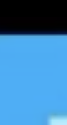


Success! Cropped image saved to: /content/Rai_Sport_HD_cropped.jpg


In [ ]:
import cv2
import ast
import os
from google.colab.patches import cv2_imshow

# 1. Set your paths here
# Replace 'sample_image.jpg' with your actual file path in Colab
image_path = '/content/Screenshot 2026-03-23 at 3.34.41 PM.png'
output_dir = '/content'

# Read the image using OpenCV
img = cv2.imread(image_path)

if img is None:
    print(f"Error: Could not read image at {image_path}. Please check the path and try again.")
else:
    print("Original image loaded successfully.")

    # 2. Ask for the bounding box data at runtime
    print("\n--- Crop Configuration ---")
    print("Please paste your dictionary list. Example: [{'brand': 'Rai', 'bbox_2d': [ymin, xmin, ymax, xmax]}]")

    user_input = input("Data: ")

    try:
        # 3. Parse the input string safely
        parsed_data = ast.literal_eval(user_input)

        # 4. Extract the data
        item = parsed_data[0]
        brand_name = item.get('brand', 'Unknown_Brand')
        bbox = item['bbox_2d']

        # According to your format: [ymin, xmin, ymax, xmax]
        ymin = int(bbox[0])
        xmin = int(bbox[1])
        ymax = int(bbox[2])
        xmax = int(bbox[3])

        print(f"\nProcessing crop for: {brand_name}")
        print(f"Coordinates -> ymin:{ymin}, xmin:{xmin}, ymax:{ymax}, xmax:{xmax}")

        # 5. Crop the Image
        cropped_img = img[ymin:ymax, xmin:xmax]

        # Check if the crop is valid
        if cropped_img.size == 0:
            print("\nError: The cropped image is empty. Please verify your coordinates are within the image dimensions.")
        else:
            # 6. Display the Result
            print("\n--- Cropped Result ---")
            cv2_imshow(cropped_img)

            # 7. Save the Cropped Image
            # Clean up the brand name to use as a valid filename (replace spaces with underscores)
            safe_filename = brand_name.replace(' ', '_') + "_cropped.jpg"
            output_path = os.path.join(output_dir, safe_filename)

            # Write the file to the /content directory
            cv2.imwrite(output_path, cropped_img)
            print(f"\nSuccess! Cropped image saved to: {output_path}")

    except (SyntaxError, ValueError):
        print("\nError: Invalid input format. Please ensure it looks exactly like your example.")
    except KeyError as e:
        print(f"\nError: Missing expected key in your data - {e}")
    except IndexError:
        print("\nError: The list you provided seems to be empty or formatted incorrectly.")
    except Exception as e:
         print(f"\nAn unexpected error occurred: {e}")